Title (Markdown)
# UEFA Champions League Finals — Data Analysis
### By Adeuya Solomon | Data Scientist
**Tools:** Python | Pandas | Matplotlib | Seaborn  
**Data Source:** Wikipedia — UCL Finals Historical Data

In [ ]:
#Project Overview
In this project I extract, clean, transform and analyze 
60+ years of UEFA Champions League finals data to uncover 
patterns in club dominance, scoring trends, and attendance history.

In [13]:
import pandas as pd
import requests 
from io import StringIO
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print("libraries loaded")

libraries loaded


In [16]:
headers = {"User-Agent": "Mozilla/5.0"}

url = "https://en.wikipedia.org/wiki/UEFA_Champions_League_final"

response = requests.get(url, headers=headers)
tables = pd.read_html(StringIO(response.text))

df_raw = max(tables, key=len)
print(f"Data extracted: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns ✅")
df_raw.head()

Data extracted: 71 rows, 8 columns ✅


,Season,Country,Winners,Score,Runners-up,Country.1,Venue,Attend­ance[16]
0,1955–56,Spain,Real Madrid,4–3,Reims,France,"Parc des Princes, Paris, France",38239
1,1956–57,Spain,Real Madrid,2–0,Fiorentina,Italy,"Santiago Bernabéu, Madrid, Spain",124000
2,1957–58,Spain,Real Madrid,3–2†,Milan,Italy,"Heysel Stadium, Brussels, Belgium",67000
3,1958–59,Spain,Real Madrid,2–0,Reims,France,"Neckarstadion, Stuttgart, West Germany",72000
4,1959–60,Spain,Real Madrid,7–3,Eintracht Frankfurt,West Germany,"Hampden Park, Glasgow, Scotland",127621


In [21]:
# TASK 2: DATA CLEANING
# ============================================================

df = df_raw.copy()

# Step 1: Rename columns cleanly
df.columns = ['Season', 'Country_Winner', 'Winner', 'Score', 
               'Runner_Up', 'Country_RunnerUp', 'Venue', 'Attendance']

# Step 2: Remove footnote numbers from text columns
import re
def clean_text(val):
    if isinstance(val, str):
        return re.sub(r'\[.*?\]', '', val).strip()
    return val

df = df.applymap(clean_text)

# Step 3: Handle missing values
df.replace(['—', '–', '', ' '], np.nan, inplace=True)
df.dropna(how='all', inplace=True)
df.reset_index(drop=True, inplace=True)

# Step 4: Split Score into Winner Goals & Runner-Up Goals
def parse_score(score):
    try:
        base = str(score).split('(')[0].strip()
        base = base.replace('–', '-').replace('−', '-')
        parts = base.split('-')
        return int(parts[0].strip()), int(parts[1].strip())
    except:
        return np.nan, np.nan

df[['Score_Winner', 'Score_RunnerUp']] = df['Score'].apply(
    lambda x: pd.Series(parse_score(x))
)

# Step 5: Match Outcome Type
def outcome_type(score):
    score = str(score).lower()
    if 'pen' in score or '(' in score and 'p' in score:
        return 'Penalty'
    elif 'a.e.t' in score or 'aet' in score:
        return 'Extra Time'
    return 'Normal'

df['Match_Outcome_Type'] = df['Score'].apply(outcome_type)

# Step 6: Extract Host Stadium from Venue
df['Host_Stadium'] = df['Venue'].str.split(',').str[0].str.strip()

# Step 7: Convert Attendance to numbers
df['Attendance'] = (
    df['Attendance'].astype(str)
    .str.replace(',', '', regex=False)
    .str.extract(r'(\d+)')[0]
    .astype(float)
)

print("Cleaned data shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Cleaned data shape: (71, 12)
Columns: ['Season', 'Country_Winner', 'Winner', 'Score', 'Runner_Up', 'Country_RunnerUp', 'Venue', 'Attendance', 'Score_Winner', 'Score_RunnerUp', 'Match_Outcome_Type', 'Host_Stadium']


,Season,Country_Winner,Winner,Score,Runner_Up,Country_RunnerUp,Venue,Attendance,Score_Winner,Score_RunnerUp,Match_Outcome_Type,Host_Stadium
0,1955–56,Spain,Real Madrid,4–3,Reims,France,"Parc des Princes, Paris, France",38239.0,4.0,3.0,Normal,Parc des Princes
1,1956–57,Spain,Real Madrid,2–0,Fiorentina,Italy,"Santiago Bernabéu, Madrid, Spain",124000.0,2.0,0.0,Normal,Santiago Bernabéu
2,1957–58,Spain,Real Madrid,3–2†,Milan,Italy,"Heysel Stadium, Brussels, Belgium",67000.0,NaN,NaN,Normal,Heysel Stadium
3,1958–59,Spain,Real Madrid,2–0,Reims,France,"Neckarstadion, Stuttgart, West Germany",72000.0,2.0,0.0,Normal,Neckarstadion
4,1959–60,Spain,Real Madrid,7–3,Eintracht Frankfurt,West Germany,"Hampden Park, Glasgow, Scotland",127621.0,7.0,3.0,Normal,Hampden Park


In [ ]:
#Task 3 (Data transformation)

In [22]:
# Step 1: Extract Year from Season (use closing year)
def extract_year(season):
    try:
        season = str(season)
        if '–' in season or '-' in season:
            parts = season.replace('–', '-').split('-')
            base_year = int(parts[0])
            closing = parts[1].strip()
            if len(closing) == 2:
                century = base_year // 100 * 100
                year = century + int(closing)
                if year < base_year:
                    year += 100
            else:
                year = int(closing)
            return year
        else:
            return int(season)
    except:
        return np.nan

df['Year'] = df['Season'].apply(extract_year)

# Step 2: Create Goal Difference
df['Goal_Difference'] = df['Score_Winner'] - df['Score_RunnerUp']

# Step 3: Create Total Goals
df['Total_Goals'] = df['Score_Winner'] + df['Score_RunnerUp']

# Preview
print("Transformation complete ✅")
print(df[['Season', 'Year', 'Score_Winner', 
          'Score_RunnerUp', 'Goal_Difference', 
          'Total_Goals']].head(10))

# Save transformed data
df.to_csv("ucl_transformed.csv", index=False)
print("Saved to ucl_transformed.csv ✅")

Transformation complete ✅
    Season  Year  Score_Winner  Score_RunnerUp  Goal_Difference  Total_Goals
0  1955–56  1956           4.0             3.0              1.0          7.0
1  1956–57  1957           2.0             0.0              2.0          2.0
2  1957–58  1958           NaN             NaN              NaN          NaN
3  1958–59  1959           2.0             0.0              2.0          2.0
4  1959–60  1960           7.0             3.0              4.0         10.0
5  1960–61  1961           3.0             2.0              1.0          5.0
6  1961–62  1962           5.0             3.0              2.0          8.0
7  1962–63  1963           2.0             1.0              1.0          3.0
8  1963–64  1964           3.0             1.0              2.0          4.0
9  1964–65  1965           1.0             0.0              1.0          1.0
Saved to ucl_transformed.csv ✅


In [23]:
# Load cleaned data
df = pd.read_csv("ucl_transformed.csv")

print("="*50)
print("UCL FINALS — 10 KEY QUESTIONS")
print("="*50)

# Q1: Top 5 clubs with most wins
print("\n1. Top 5 clubs with most wins:")
q1 = df['Winner'].value_counts().head(5)
print(q1)

# Q2: Top 5 nations by titles
print("\n2. Top 5 nations by titles:")
q2 = df['Country_Winner'].value_counts().head(5)
print(q2)

# Q3: Average attendance over time
print("\n3. Average attendance overall:")
q3 = df['Attendance'].mean()
print(f"{q3:,.0f}")

# Q4: Most common scoreline
print("\n4. Most common scorelines:")
q4 = df['Score'].value_counts().head(5)
print(q4)

# Q5: Average goals per final
print("\n5. Average goals per final:")
q5 = df['Total_Goals'].mean()
print(f"{q5:.2f}")

# Q6: Attendance trend by decade
print("\n6. Attendance trend by decade:")
df['Decade'] = (df['Year'] // 10 * 10).astype('Int64')
q6 = df.groupby('Decade')['Attendance'].mean().dropna()
print(q6.apply(lambda x: f"{x:,.0f}"))

# Q7: Country that hosted most finals
print("\n7. Country hosting most finals:")
q7 = df['Country_Winner'].value_counts().head(5)
print(q7)

# Q8: Stadium that hosted most finals
print("\n8. Stadium hosting most finals:")
q8 = df['Host_Stadium'].value_counts().head(5)
print(q8)

# Q9: Total goals trend over time
print("\n9. Total goals per year (last 10):")
q9 = df.groupby('Year')['Total_Goals'].sum().dropna()
print(q9.tail(10))

# Q10: Club with most runner-up finishes
print("\n10. Most runner-up finishes:")
q10 = df['Runner_Up'].value_counts().head(5)
print(q10)

UCL FINALS — 10 KEY QUESTIONS

1. Top 5 clubs with most wins:
Winner
Real Madrid      15
Milan             7
Bayern Munich     7
Liverpool         6
Barcelona         5
Name: count, dtype: int64

2. Top 5 nations by titles:
Country_Winner
Spain           20
England         15
Italy           12
Netherlands      6
West Germany     5
Name: count, dtype: int64

3. Average attendance overall:
64,293

4. Most common scorelines:
Score
1–0     18
2–1      9
2–0      9
3–1      6
1–1*     6
Name: count, dtype: int64

5. Average goals per final:
2.74

6. Attendance trend by decade:
Decade
1950    75,310
1960    63,741
1970    60,863
1980    63,905
1990    63,626
2000    66,625
2010    70,402
2020    51,844
Name: Attendance, dtype: object

7. Country hosting most finals:
Country_Winner
Spain           20
England         15
Italy           12
Netherlands      6
West Germany     5
Name: count, dtype: int64

8. Stadium hosting most finals:
Host_Stadium
Wembley Stadium      8
Heysel Stadium       5


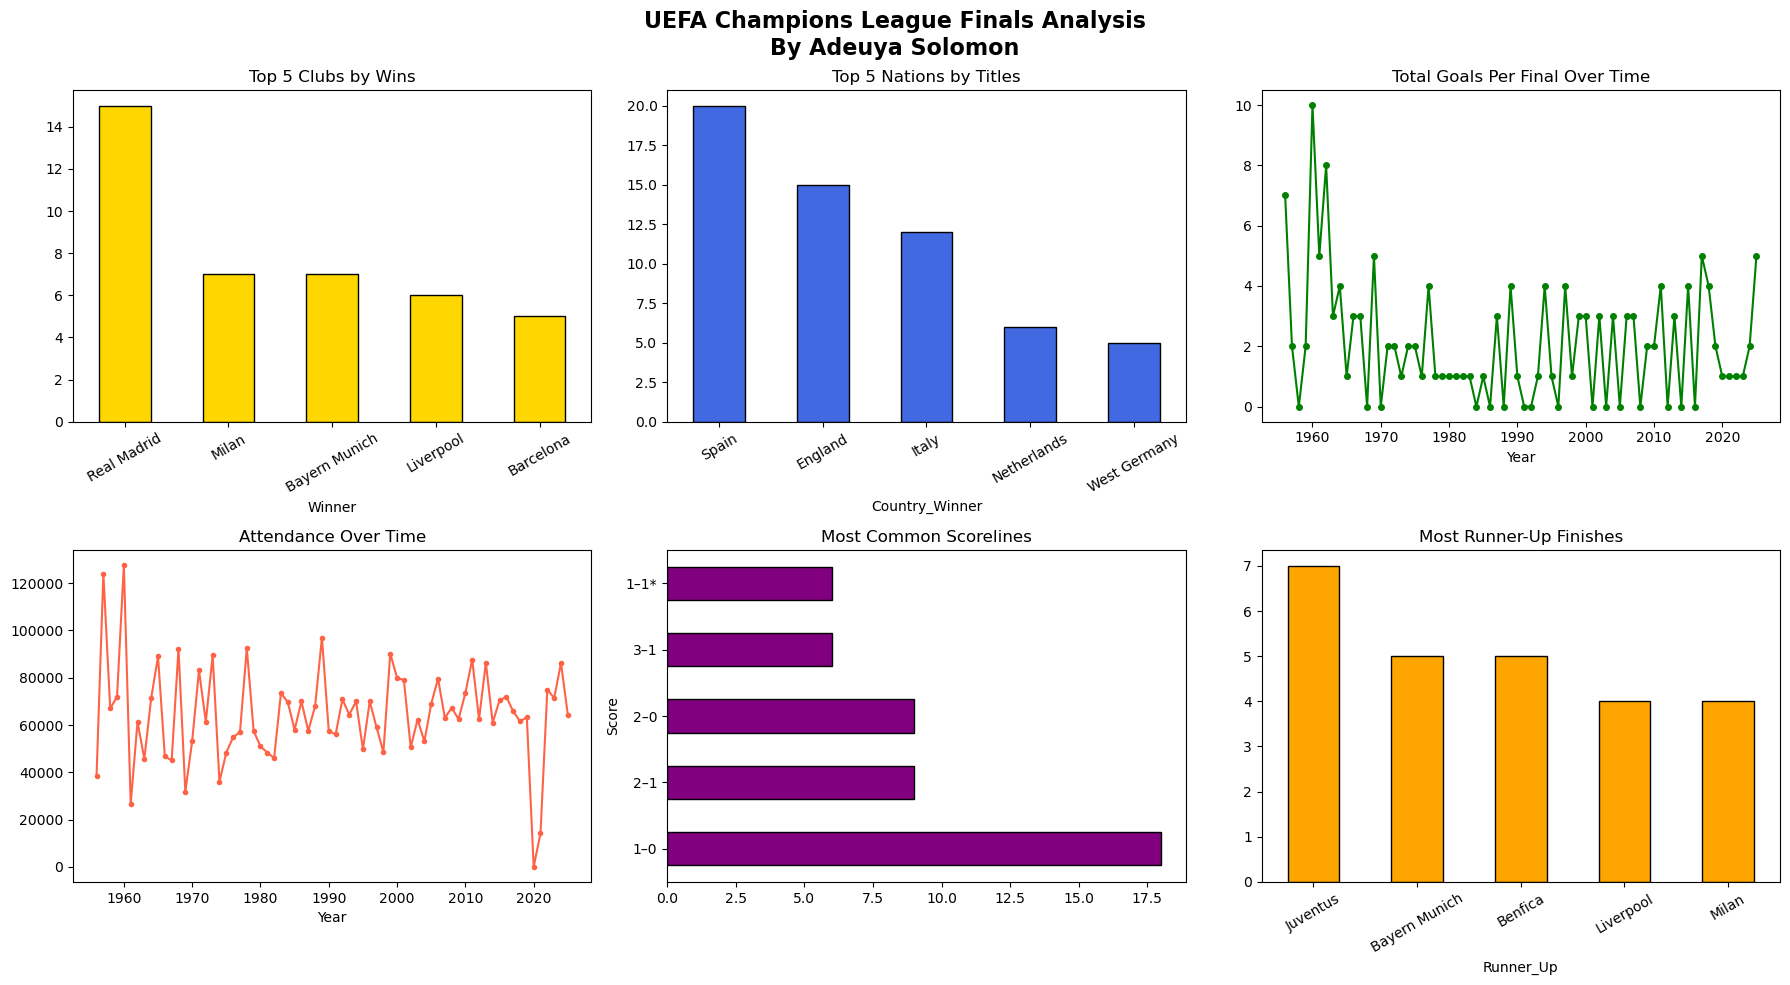


✅ All done! Charts saved to ucl_analysis.png


In [24]:
# VISUALIZATIONS
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('UEFA Champions League Finals Analysis\nBy Adeuya Solomon', 
             fontsize=16, fontweight='bold')

# Chart 1: Top 5 winners
q1.plot(kind='bar', ax=axes[0,0], color='gold', edgecolor='black')
axes[0,0].set_title('Top 5 Clubs by Wins')
axes[0,0].tick_params(axis='x', rotation=30)

# Chart 2: Top nations
q2.plot(kind='bar', ax=axes[0,1], color='royalblue', edgecolor='black')
axes[0,1].set_title('Top 5 Nations by Titles')
axes[0,1].tick_params(axis='x', rotation=30)

# Chart 3: Goals trend
q9.plot(ax=axes[0,2], color='green', marker='o', markersize=4)
axes[0,2].set_title('Total Goals Per Final Over Time')
axes[0,2].set_xlabel('Year')

# Chart 4: Attendance trend
df.groupby('Year')['Attendance'].mean().dropna().plot(
    ax=axes[1,0], color='tomato', marker='o', markersize=3)
axes[1,0].set_title('Attendance Over Time')
axes[1,0].set_xlabel('Year')

# Chart 5: Most common scorelines
q4.head(5).plot(kind='barh', ax=axes[1,1], color='purple', edgecolor='black')
axes[1,1].set_title('Most Common Scorelines')

# Chart 6: Top runner-ups
q10.plot(kind='bar', ax=axes[1,2], color='orange', edgecolor='black')
axes[1,2].set_title('Most Runner-Up Finishes')
axes[1,2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('ucl_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ All done! Charts saved to ucl_analysis.png")